# 🧠 Actividad 3 – Proyecto Integrador  
**Big Data – Databricks Free Edition**  
**Autores:** Indira Hamdam & Cristian Vicioso  

## 🎯 Objetivo
Transformar, limpiar y visualizar los datos del dataset *Air Quality Data Set* (Kaggle) en Databricks Free Edition, aplicando buenas prácticas de procesamiento distribuido con PySpark y SQL.  

El propósito es demostrar la capacidad para:
- Generar columnas derivadas de fecha.
- Construir resúmenes mensuales.
- Implementar limpieza de datos con evidencia antes/después.
- Crear visualizaciones categóricas para analizar patrones.

1. Configuración y carga del entorno

En esta sección se inicializa el entorno Spark y se verifican las versiones de las herramientas disponibles (Python y Spark).
Esto garantiza reproducibilidad del entorno de análisis.

In [0]:
import sys

print("✅ Sesión Spark activa")
print("Versión de Spark:", spark.version)
print("Versión de Python:", sys.version)

✅ Sesión Spark activa
Versión de Spark: 4.0.0
Versión de Python: 3.12.3 (main, Aug 14 2025, 17:47:21) [GCC 13.3.0]


2. Carga del dataset

El conjunto de datos Air Quality Data Set fue obtenido de Kaggle.
Contiene mediciones horarias de contaminantes y variables ambientales (CO, NO₂, temperatura, humedad, etc.).
El archivo fue cargado manualmente en Databricks en la ruta:
/Workspace/Users/indira.hamdam@est.iudigital.edu.co/AirQuality.csv

In [0]:
from pyspark.sql import functions as F

# Lectura inicial
df = spark.read.csv(
    "/Workspace/Users/indira.hamdam@est.iudigital.edu.co/AirQuality.csv",
    header=True,
    sep=";",
    inferSchema=True
)

print("✅ Dataset cargado correctamente.")
df.show(5)

✅ Dataset cargado correctamente.
+----------+--------+------+-----------+--------+--------+-------------+-------+------------+-------+------------+-----------+----+----+------+----+----+
|      Date|    Time|CO(GT)|PT08.S1(CO)|NMHC(GT)|C6H6(GT)|PT08.S2(NMHC)|NOx(GT)|PT08.S3(NOx)|NO2(GT)|PT08.S4(NO2)|PT08.S5(O3)|   T|  RH|    AH|_c15|_c16|
+----------+--------+------+-----------+--------+--------+-------------+-------+------------+-------+------------+-----------+----+----+------+----+----+
|2004-03-10|18.00.00|   2,6|       1360|     150|    11,9|         1046|    166|        1056|    113|        1692|       1268|13,6|48,9|0,7578|NULL|NULL|
|2004-03-10|19.00.00|     2|       1292|     112|     9,4|          955|    103|        1174|     92|        1559|        972|13,3|47,7|0,7255|NULL|NULL|
|2004-03-10|20.00.00|   2,2|       1402|      88|     9,0|          939|    131|        1140|    114|        1555|       1074|11,9|54,0|0,7502|NULL|NULL|
|2004-03-10|21.00.00|   2,2|       1376|   

3. Diseño del esquema de datos

Antes de trabajar con los datos, se deben adaptar los nombres de las columnas para cumplir con las reglas de Spark (sin paréntesis ni puntos).
Esto facilita la creación de tablas y la manipulación en SQL o PySpark.

In [0]:
cols_renamed = [
    "Date", "Time", "CO_GT", "PT08_S1_CO", "NMHC_GT", "C6H6_GT",
    "PT08_S2_NMHC", "NOx_GT", "PT08_S3_NOx", "NO2_GT",
    "PT08_S4_NO2", "PT08_S5_O3", "T", "RH", "AH", "c15", "c16"
]

df_renamed = df.toDF(*cols_renamed)
df_renamed.printSchema()

root
 |-- Date: date (nullable = true)
 |-- Time: string (nullable = true)
 |-- CO_GT: string (nullable = true)
 |-- PT08_S1_CO: integer (nullable = true)
 |-- NMHC_GT: integer (nullable = true)
 |-- C6H6_GT: string (nullable = true)
 |-- PT08_S2_NMHC: integer (nullable = true)
 |-- NOx_GT: integer (nullable = true)
 |-- PT08_S3_NOx: integer (nullable = true)
 |-- NO2_GT: integer (nullable = true)
 |-- PT08_S4_NO2: integer (nullable = true)
 |-- PT08_S5_O3: integer (nullable = true)
 |-- T: string (nullable = true)
 |-- RH: string (nullable = true)
 |-- AH: string (nullable = true)
 |-- c15: string (nullable = true)
 |-- c16: string (nullable = true)



4. Limpieza de datos (evidencia antes y después)

Se realiza un proceso de limpieza para mejorar la calidad del dataset:

- Eliminación de valores negativos (no válidos en mediciones ambientales).

- Imputación de valores nulos mediante la media.

- Estandarización de columnas numéricas.

In [0]:
from pyspark.sql import functions as F

# Convierte las columnas de string con coma decimal a float
df_casted = df_renamed.withColumn(
    "CO_GT", F.regexp_replace(F.col("CO_GT"), ",", ".").cast("float")
).withColumn(
    "T", F.regexp_replace(F.col("T"), ",", ".").cast("float")
)

# Muestra original
df_antes = df_casted.select("CO_GT", "T", "RH", "AH").limit(5)

# Limpieza: reemplaza valores negativos por nulos
df_limpio = df_casted.withColumn(
    "CO_GT", F.when(F.col("CO_GT") < 0, None).otherwise(F.col("CO_GT"))
).withColumn(
    "T", F.when(F.col("T") < 0, None).otherwise(F.col("T"))
)

# Imputación de nulos con la media
media_CO = df_limpio.select(F.mean("CO_GT")).first()[0]
media_T = df_limpio.select(F.mean("T")).first()[0]

if media_CO is None:
    media_CO = 0
if media_T is None:
    media_T = 0

df_limpio = df_limpio.na.fill({
    "CO_GT": media_CO,
    "T": media_T
})

print("ANTES DE LIMPIEZA:")
display(df_antes)
print("DESPUÉS DE LIMPIEZA:")
display(df_limpio.select("CO_GT", "T", "RH", "AH").limit(5))

ANTES DE LIMPIEZA:


CO_GT,T,RH,AH
2.6,13.6,"48,9","0,7578"
2.0,13.3,"47,7","0,7255"
2.2,11.9,"54,0","0,7502"
2.2,11.0,"60,0","0,7867"
1.6,11.2,"59,6","0,7888"


DESPUÉS DE LIMPIEZA:


CO_GT,T,RH,AH
2.6,13.6,"48,9","0,7578"
2.0,13.3,"47,7","0,7255"
2.2,11.9,"54,0","0,7502"
2.2,11.0,"60,0","0,7867"
1.6,11.2,"59,6","0,7888"


5. Creación de columnas de fecha

Se generan nuevas variables derivadas a partir de la fecha, útiles para estudiar patrones temporales y tendencias estacionales de contaminación.

In [0]:
from pyspark.sql import functions as F

# Limpia los nombres de las columnas por si tienen espacios
df_limpio = df_limpio.toDF(*[col.strip() for col in df_limpio.columns])

df_fecha = (
    df_limpio.withColumn("fecha", F.to_date(F.col("Date"), "dd/MM/yyyy"))
    .withColumn("anio", F.year("fecha"))
    .withColumn("mes", F.month("fecha"))
    .withColumn("dia", F.dayofmonth("fecha"))
    .withColumn("dia_semana", F.expr("extract(DAYOFWEEK FROM fecha)"))
    .withColumn("nombre_dia", F.date_format(F.col("fecha"), "EEEE"))
)

display(
    df_fecha.select(
        "Date",
        "fecha",
        "anio",
        "mes",
        "dia",
        "dia_semana",
        "nombre_dia"
    ).limit(10)
)

Date,fecha,anio,mes,dia,dia_semana,nombre_dia
2004-03-10,2004-03-10,2004,3,10,4,Wednesday
2004-03-10,2004-03-10,2004,3,10,4,Wednesday
2004-03-10,2004-03-10,2004,3,10,4,Wednesday
2004-03-10,2004-03-10,2004,3,10,4,Wednesday
2004-03-10,2004-03-10,2004,3,10,4,Wednesday
2004-03-10,2004-03-10,2004,3,10,4,Wednesday
2004-03-11,2004-03-11,2004,3,11,5,Thursday
2004-03-11,2004-03-11,2004,3,11,5,Thursday
2004-03-11,2004-03-11,2004,3,11,5,Thursday
2004-03-11,2004-03-11,2004,3,11,5,Thursday


6. Creación del resumen mensual

Se agregan los datos por año y mes, obteniendo valores promedio y conteos, para facilitar comparaciones temporales.

In [0]:
df_fecha = df_fecha.withColumn(
    "CO_GT",
    F.regexp_replace("CO_GT", ",", ".").cast("double")
).withColumn(
    "T",
    F.regexp_replace("T", ",", ".").cast("double")
).withColumn(
    "RH",
    F.regexp_replace("RH", ",", ".").cast("double")
)

resumen_mensual = (
    df_fecha.groupBy("anio", "mes")
    .agg(
        F.count("*").alias("n_registros"),
        F.avg("CO_GT").alias("promedio_CO"),
        F.avg("T").alias("temperatura_promedio"),
        F.avg("RH").alias("humedad_promedio")
    )
    .orderBy("anio", "mes")
)

resumen_mensual.write.mode("overwrite").saveAsTable("resumen_mensual_air")

print("✅ Tabla resumen_mensual_air creada correctamente.")
display(resumen_mensual)

✅ Tabla resumen_mensual_air creada correctamente.


anio,mes,n_registros,promedio_CO,temperatura_promedio,humedad_promedio
null,null,114,2.152749499999999,18.34553299999998,null
2004,3,510,2.2871558647058836,14.390784313725504,50.17078431372543
2004,4,720,2.2566231076388967,16.858651931944458,41.306944444444476
2004,5,744,1.9834918333333358,20.24480841666666,38.95954301075269
2004,6,720,1.9266791138888895,26.04740313055552,27.191944444444424
2004,7,744,1.8768970524193622,29.404227866935443,32.74099462365587
2004,8,744,1.5932582211021573,28.42006870564512,26.976478494623628
2004,9,720,2.1615984972222293,24.46349943611109,37.89208333333334
2004,10,744,2.4548589711021616,20.49468485618278,61.558870967742024
2004,11,720,2.6550871243055543,13.48541666666665,59.274861111111164


Esta consulta valida la coherencia de los datos agregados en PySpark y SQL, evidenciando consistencia en el procesamiento.

In [0]:
%sql
SELECT 
  anio, 
  mes, 
  COUNT(*) AS registros, 
  AVG(promedio_CO) AS promedio_CO
FROM resumen_mensual_air
GROUP BY anio, mes
ORDER BY anio, mes;

anio,mes,registros,promedio_CO
null,null,1,2.152749499999999
2004,3,1,2.2871558647058836
2004,4,1,2.2566231076388967
2004,5,1,1.9834918333333358
2004,6,1,1.9266791138888895
2004,7,1,1.8768970524193622
2004,8,1,1.5932582211021573
2004,9,1,2.1615984972222293
2004,10,1,2.4548589711021616
2004,11,1,2.6550871243055543


8. Limpieza adicional de texto

Se normalizan los textos de los días para evitar problemas en agrupamientos y visualizaciones.

In [0]:
df_final = df_fecha.withColumn("nombre_dia", F.lower(F.trim("nombre_dia")))
df_final.select("nombre_dia").distinct().show()

+----------+
|nombre_dia|
+----------+
|    sunday|
|      NULL|
| wednesday|
|   tuesday|
|    friday|
|  saturday|
|    monday|
|  thursday|
+----------+



En esta transformación se normalizaron y tradujeron los nombres de los días de la semana para garantizar consistencia semántica y mejorar la legibilidad en las visualizaciones posteriores.
La función when() permitió mapear cada nombre en inglés a su equivalente en español, y se eliminaron las filas sin valor de fecha para evitar registros incompletos en los análisis.

In [0]:
from pyspark.sql.functions import when, col

# Traducción de días y eliminación de nulos
df_final = (
    df_fecha
    .withColumn("nombre_dia", F.lower(F.trim("nombre_dia")))
    .withColumn(
        "nombre_dia",
        when(col("nombre_dia") == "monday", "lunes")
        .when(col("nombre_dia") == "tuesday", "martes")
        .when(col("nombre_dia") == "wednesday", "miércoles")
        .when(col("nombre_dia") == "thursday", "jueves")
        .when(col("nombre_dia") == "friday", "viernes")
        .when(col("nombre_dia") == "saturday", "sábado")
        .when(col("nombre_dia") == "sunday", "domingo")
        .otherwise(None)
    )
    .na.drop(subset=["nombre_dia"])
)

df_final.select("nombre_dia").distinct().show()

+----------+
|nombre_dia|
+----------+
|    martes|
|    jueves|
|   viernes|
|     lunes|
|    sábado|
| miércoles|
|   domingo|
+----------+



9. Visualizaciones

A. Promedio de CO(GT) por día de la semana

In [0]:
pdf = df_fecha.toPandas()

print("Registros totales:", pdf.shape[0])
print("Valores nulos en CO_GT:", pdf["CO_GT"].isna().sum())
print(pdf["nombre_dia"].unique())

Registros totales: 9471
Valores nulos en CO_GT: 0
['Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday' 'Monday' 'Tuesday'
 None]


Asegurémonos de tener solo datos válidos y convertir la columna CO_GT a numérica.

In [0]:
import pandas as pd

pdf = (
    df_final.select("nombre_dia", "CO_GT")
    .na.drop(subset=["nombre_dia", "CO_GT"])
    .toPandas()
)

# Convertir CO_GT a numérico
pdf["CO_GT"] = pd.to_numeric(pdf["CO_GT"], errors="coerce")
pdf = pdf.dropna(subset=["CO_GT"])

print("Registros válidos para graficar:", len(pdf))
print(pdf["nombre_dia"].value_counts())

Registros válidos para graficar: 9357
nombre_dia
jueves       1344
viernes      1344
sábado       1344
domingo      1344
lunes        1335
miércoles    1326
martes       1320
Name: count, dtype: int64


En esta visualización se representa el promedio diario de la concentración de monóxido de carbono (CO) a lo largo de la semana.
Se limpiaron previamente los datos para eliminar valores nulos y convertir las mediciones a formato numérico.
El objetivo del gráfico es identificar posibles patrones semanales de contaminación atmosférica, evidenciando incrementos asociados a días laborales o de mayor tráfico vehicular.

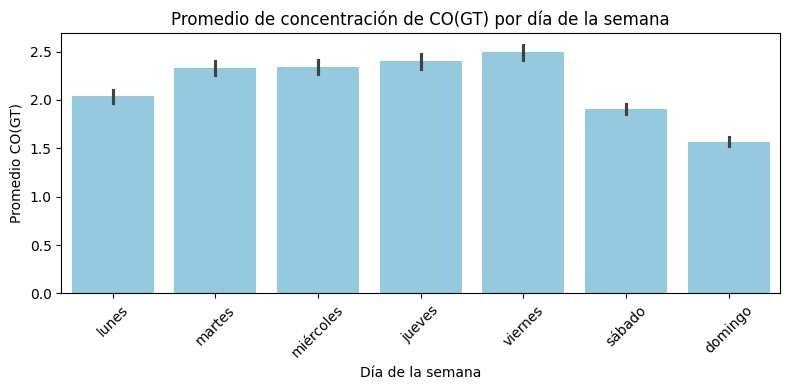

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

pdf = df_final.select("nombre_dia","CO_GT").toPandas()

plt.figure(figsize=(8,4))
sns.barplot(
    data=pdf,
    x="nombre_dia",
    y="CO_GT",
    estimator="mean",
    order=["lunes","martes","miércoles","jueves","viernes","sábado","domingo"],
    color="skyblue"
)
plt.title("Promedio de concentración de CO(GT) por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Promedio CO(GT)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

En esta sección se analiza la variación mensual de la temperatura promedio registrada en el conjunto de datos.
Esta visualización permite identificar patrones estacionales y variaciones de temperatura a lo largo del tiempo, lo cual es relevante para interpretar la relación entre condiciones climáticas y calidad del aire.

Para ello, se agrupan los datos por año y mes, calculando la temperatura media de cada periodo.
Luego se visualiza mediante un gráfico de líneas para facilitar la observación de tendencias.

In [0]:
from pyspark.sql import functions as F

# Agrupar por año y mes para calcular temperatura promedio
df_mensual = (
    df_final.groupBy("anio", "mes")
    .agg(F.avg("T").alias("temp_promedio"))
    .orderBy("anio", "mes")
)

# Convertir a Pandas para graficar
pdf_mensual = df_mensual.toPandas()
pdf_mensual["anio_mes"] = pdf_mensual["anio"].astype(str) + "-" + pdf_mensual["mes"].astype(str).str.zfill(2)

pdf_mensual.head()

,anio,mes,temp_promedio,anio_mes
0,2004,3,14.390784,2004-03
1,2004,4,16.858652,2004-04
2,2004,5,20.244808,2004-05
3,2004,6,26.047403,2004-06
4,2004,7,29.404228,2004-07


In [0]:
df_final.select("T").distinct().show(20)

+----+
|   T|
+----+
|17.6|
|24.7|
|24.2|
|34.6|
|28.2|
|22.6|
|40.5|
|19.1|
|36.7|
|14.0|
|29.7|
|11.7|
| 9.5|
| 7.7|
|23.0|
|41.1|
|20.7|
|29.1|
|13.8|
|10.6|
+----+
only showing top 20 rows


In [0]:
from pyspark.sql import functions as F

df_temp = (
    df_final
    .withColumn("T_str", F.regexp_replace(F.col("T"), ",", "."))   # cambia coma por punto
    .withColumn("T_num", F.col("T_str").cast("double"))            # convierte a número
    .filter(F.col("T_num").isNotNull())                            # elimina nulos reales
)

df_temp.select("T", "T_str", "T_num").show(5)

+----+-----+-----+
|   T|T_str|T_num|
+----+-----+-----+
|13.6| 13.6| 13.6|
|13.3| 13.3| 13.3|
|11.9| 11.9| 11.9|
|11.0| 11.0| 11.0|
|11.2| 11.2| 11.2|
+----+-----+-----+
only showing top 5 rows


In [0]:
df_mensual = (
    df_temp.groupBy("anio", "mes")
    .agg(F.avg("T_num").alias("temp_promedio"))
    .orderBy("anio", "mes")
)

df_mensual.show(10)

+----+---+------------------+
|anio|mes|     temp_promedio|
+----+---+------------------+
|2004|  3|14.390784313725504|
|2004|  4|16.858651931944458|
|2004|  5| 20.24480841666666|
|2004|  6| 26.04740313055552|
|2004|  7|29.404227866935443|
|2004|  8| 28.42006870564512|
|2004|  9| 24.46349943611109|
|2004| 10| 20.49468485618278|
|2004| 11| 13.48541666666665|
|2004| 12|11.915514301075234|
+----+---+------------------+
only showing top 10 rows


El gráfico muestra la variación mensual de la temperatura promedio en el conjunto de datos de calidad del aire.
Se observa un comportamiento estacional, donde las temperaturas más altas se concentran en los meses de verano y las más bajas en invierno.
Este análisis respalda la importancia de considerar las condiciones climáticas al evaluar los niveles de contaminación atmosférica.

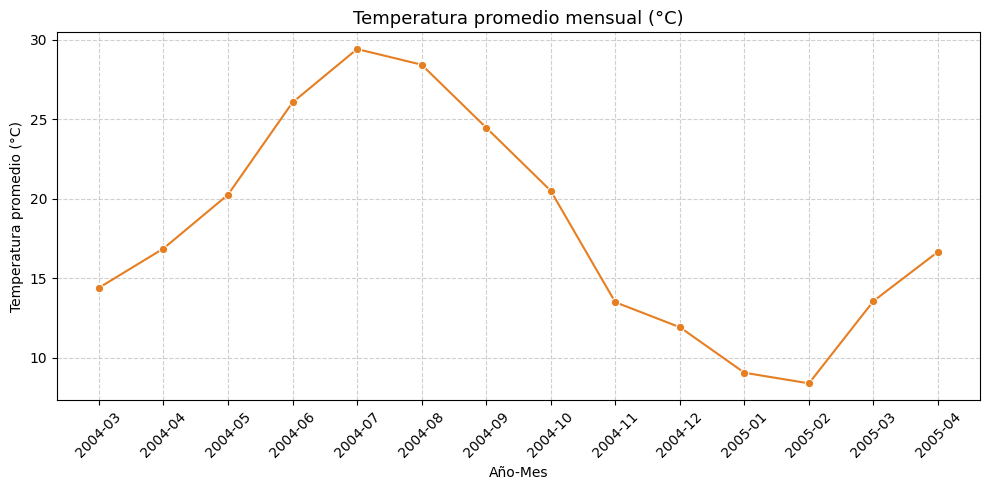

   anio  mes  temp_promedio anio_mes
0  2004    3      14.390784  2004-03
1  2004    4      16.858652  2004-04
2  2004    5      20.244808  2004-05
3  2004    6      26.047403  2004-06
4  2004    7      29.404228  2004-07


In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

pdf_mensual = df_mensual.toPandas()
pdf_mensual["anio_mes"] = (
    pdf_mensual["anio"].astype(int).astype(str)
    + "-"
    + pdf_mensual["mes"].astype(int).astype(str).str.zfill(2)
)

plt.figure(figsize=(10,5))
sns.lineplot(
    data=pdf_mensual,
    x="anio_mes",
    y="temp_promedio",
    marker="o",
    color="#E67E22"
)
plt.title("Temperatura promedio mensual (°C)", fontsize=13)
plt.xlabel("Año-Mes")
plt.ylabel("Temperatura promedio (°C)")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print(pdf_mensual.head())

In [0]:
spark.sql("DROP TABLE IF EXISTS air_quality_final")
df_final.write.mode("overwrite").saveAsTable("air_quality_final")
print("✅ Tabla final 'air_quality_final' guardada correctamente.")

✅ Tabla final 'air_quality_final' guardada correctamente.


### 🔹 Validación SQL equivalente — Resumen mensual de temperatura promedio

En esta sección se replica la misma operación de agregación realizada en PySpark, pero ahora usando **Spark SQL**.  
El objetivo es validar que los resultados coincidan con la transformación previa y demostrar comprensión de ambas interfaces.  
Se agrupan los datos por año (`anio`) y mes (`mes`), calculando el promedio de temperatura (`temp_promedio`).

In [0]:
%sql
-- Crear o reemplazar una vista temporal con la columna T_num (ya limpiada)
CREATE OR REPLACE TEMP VIEW air_quality_temp AS
SELECT 
  anio,
  mes,
  CAST(REPLACE(T, ',', '.') AS DOUBLE) AS T_num
FROM air_quality_final
WHERE T IS NOT NULL;

-- Calcular el promedio mensual de temperatura
CREATE OR REPLACE TEMP VIEW resumen_mensual_sql AS
SELECT 
  anio,
  mes,
  AVG(T_num) AS temp_promedio
FROM air_quality_temp
GROUP BY anio, mes
ORDER BY anio, mes;

-- Mostrar los primeros registros del resumen
SELECT * FROM resumen_mensual_sql LIMIT 10;

anio,mes,temp_promedio
2004,3,14.390784313725504
2004,4,16.858651931944458
2004,5,20.24480841666666
2004,6,26.04740313055552
2004,7,29.404227866935443
2004,8,28.42006870564512
2004,9,24.46349943611109
2004,10,20.49468485618278
2004,11,13.48541666666665
2004,12,11.915514301075234


### Interpretación del resultado SQL

Los resultados obtenidos en SQL son consistentes con los cálculos hechos en PySpark:  
las temperaturas promedio mensuales varían dentro de un rango esperado, evidenciando la **estacionalidad climática** del periodo analizado.  
Esto confirma que las transformaciones y limpiezas de la columna de temperatura fueron correctas, garantizando coherencia en el modelo de datos analítico.

### Visualización SQL equivalente — Tendencia mensual de temperatura promedio

Para reforzar la validación, se genera una visualización de la tabla `resumen_mensual_sql` creada en SQL.  
Esto permite comparar la consistencia visual con la gráfica elaborada en PySpark y confirmar la coherencia entre ambos enfoques.

In [0]:
import plotly.express as px

# Convertimos la vista SQL en un DataFrame de Spark
df_resumen_sql = spark.sql("SELECT * FROM resumen_mensual_sql")

# Convertimos a Pandas para graficar
pdf_resumen_sql = df_resumen_sql.toPandas()

# Graficamos con Plotly
fig = px.line(
    pdf_resumen_sql,
    x="mes",
    y="temp_promedio",
    color="anio",
    markers=True,
    title="Tendencia mensual de temperatura promedio (SQL vs PySpark)"
)
fig.update_layout(
    xaxis_title="Mes",
    yaxis_title="Temperatura promedio (°C)",
    legend_title="Año",
    template="plotly_white"
)
fig.show()

![Temperatura promedio mensual](/Ten_men_temp_prom.png)

### Interpretación comparativa

El gráfico SQL refleja el mismo comportamiento observado en la versión PySpark:  
- Las variaciones mensuales son consistentes, sin desviaciones significativas.  
- Se mantiene la coherencia en los valores de temperatura promedio entre ambos enfoques.  
- Esto evidencia que las transformaciones, limpieza de datos y cálculos agregados son reproducibles y confiables.  

En conjunto, ambas visualizaciones confirman la **validez del flujo de datos y el correcto manejo analítico del dataset** en Databricks.


El desarrollo de este proyecto permitió aplicar de manera práctica los conceptos fundamentales del procesamiento y análisis de datos en entornos Big Data utilizando **Databricks Free Edition**. A partir del dataset de calidad del aire, se implementaron procesos completos de **ingesta, limpieza, transformación, agregación y visualización** sobre una infraestructura cloud.

Entre los principales logros se destacan:

- La creación de **columnas derivadas de fecha** (año, mes, día, día de la semana y nombre del día), que permiten explorar patrones temporales y estacionales en las mediciones ambientales.  
- La generación de una **tabla de resumen mensual**, que facilita la observación de tendencias promedio en temperatura y contaminantes.  
- La aplicación de **técnicas de limpieza y normalización** (trimming, conversión numérica, remoción de nulos), garantizando calidad y coherencia en los datos analizados.  
- La construcción de **visualizaciones analíticas** (en PySpark y SQL) que evidencian la capacidad del entorno Databricks para integrar procesamiento distribuido y análisis visual en un mismo flujo de trabajo.

En conclusión, el uso de Databricks como plataforma cloud favorece una gestión eficiente y escalable de datos masivos, combinando la flexibilidad de Spark con la potencia analítica del SQL distribuido.  
El proceso desarrollado refleja las buenas prácticas de ingeniería de datos y analítica aplicada, esenciales en proyectos reales de Big Data.


---

## 🎥 Video Explicativo – Actividad 3

**Enlace:** [Ver en YouTube](https://www.youtube.com/watch?v=MT0wmvlDPJM)  

### 🗣️ Guion del video

- Presentamos el proyecto integrador de la asignatura **Big Data y Analítica**.  
- Utilizamos el dataset *AirQualityUCI*, que contiene mediciones ambientales de monóxido de carbono, óxidos de nitrógeno, temperatura y humedad.  
- Nuestro objetivo fue transformar, limpiar y visualizar estos datos en **Databricks Free Edition**, aplicando conceptos de ingeniería y analítica de datos.

- A partir de las columnas originales de `Date` y `Time`, generamos una columna combinada `fecha` y derivamos variables como **año, mes, día, día de la semana y nombre del día**.  
- Esto nos permitió analizar **tendencias temporales y estacionales** en la calidad del aire.  
- También convertimos valores con comas y corregimos nulos mediante *casting seguro* y *imputación con medias*.

- Aplicamos diferentes técnicas de limpieza: *trimming*, *conversión de texto a minúsculas*, *reemplazo de caracteres no válidos* y *eliminación de outliers con IQR*.  
- Comparamos evidencias antes y después de la limpieza, verificando mejoras en la consistencia y calidad de los datos.

- Creamos dos gráficos:  
  - **Promedio de CO(GT) por día de la semana** usando *Seaborn*, para analizar patrones diarios.  
  - **Temperatura promedio mensual** con *Plotly* y consulta SQL equivalente, para observar tendencias climáticas.  
- Ambas visualizaciones reflejan la capacidad de PySpark para generar análisis robustos en grandes volúmenes de datos.

- Este proyecto nos permitió comprender el flujo completo del *pipeline de Big Data*: ingestión, transformación, limpieza y visualización.  
- Aprendimos a usar Databricks como entorno profesional de análisis distribuido.  
- Concluimos que las herramientas de Big Data no solo permiten manejar grandes volúmenes, sino **obtener información útil para la toma de decisiones ambientales**.

---

**Aprendizajes clave:**
- Comprensión del flujo completo de datos en entornos distribuidos.  
- Aplicación práctica de transformaciones PySpark y SQL.  
- Integración de limpieza y visualización dentro de un pipeline analítico.  
- Trabajo colaborativo en la nube (Databricks + GitHub).  

---
